<a href="https://colab.research.google.com/github/raliaskarov/tutorial_maths_demo/blob/main/Logistic_regress_%26_Logistic_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import packages

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import numpy as np


---
## Sigmoid Activation Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Key properties:**
- $\sigma(0) = 0.5$ — boundary between classes
- $\sigma(z) \to 1$ as $z \to +\infty$,  $\sigma(z) \to 0$ as $z \to -\infty$
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — needed for backprop

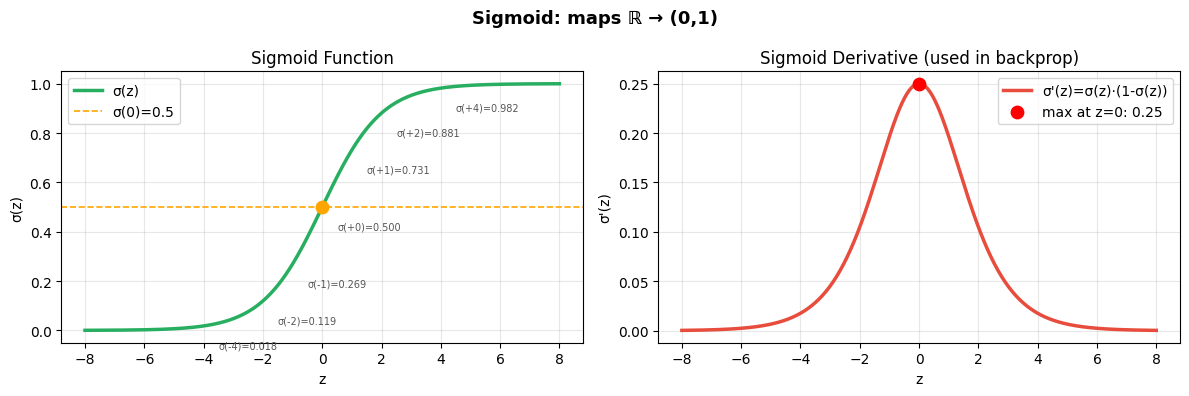

 Paper reference table:
    z      σ(z)
----------------
   -4    0.0180
   -2    0.1192
   -1    0.2689
    0    0.5000  ← decision boundary
    1    0.7311
    2    0.8808
    4    0.9820


In [47]:
#plt.style.use('seaborn-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
z = np.linspace(-8, 8, 400)
sig = 1 / (1 + np.exp(-z))
sig_d = sig * (1 - sig)

ax1.plot(z, sig, color='#27ae60', lw=2.5, label='σ(z)')
ax1.axhline(0.5, color='orange', ls='--', lw=1.2, label='σ(0)=0.5')
ax1.scatter([0],[0.5], color='orange', s=80, zorder=5)
ax1.set(xlabel='z', ylabel='σ(z)', title='Sigmoid Function', ylim=(-0.05,1.05))
ax1.legend(); ax1.grid(True, alpha=0.3)
for zv in [-4,-2,-1,0,1,2,4]:
    sv = 1/(1+np.exp(-zv))
    ax1.annotate(f'σ({zv:+d})={sv:.3f}', xy=(zv,sv), xytext=(zv+0.5,sv-0.09), fontsize=7, color='#555')

ax2.plot(z, sig_d, color='#e74c3c', lw=2.5, label="σ'(z)=σ(z)·(1-σ(z))")
ax2.scatter([0],[0.25], color='red', s=80, zorder=5, label="max at z=0: 0.25")
ax2.set(xlabel='z', ylabel="σ'(z)", title='Sigmoid Derivative (used in backprop)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Sigmoid: maps ℝ → (0,1)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(' Paper reference table:')
print(f'{"z":>5}  {"σ(z)":>8}')
print('-'*16)
for zv in [-4,-2,-1,0,1,2,4]:
    print(f'{zv:>5}  {1/(1+np.exp(-zv)):>8.4f}{"  ← decision boundary" if zv==0 else ""}')

---
## Binary Cross-Entropy Loss

$$\mathcal{L}(y, \hat{y}) = -\bigl[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})\bigr]$$

| y | simplifies to | behaviour |
|:---:|:---|:---|
| 1 | $-\log(\hat{y})$ | → 0 when ŷ → 1 |
| 0 | $-\log(1-\hat{y})$ | → 0 when ŷ → 0 |

Cancellation with sigmoid

Substituting $\hat{y}=\sigma(z)$ into BCE and differentiating:

$$\frac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$$

The $e$ and $\log$ cancel completely — the gradient is just prediction minus truth

Text(0.25, 1.5, 'low loss\nwhen ŷ→0')

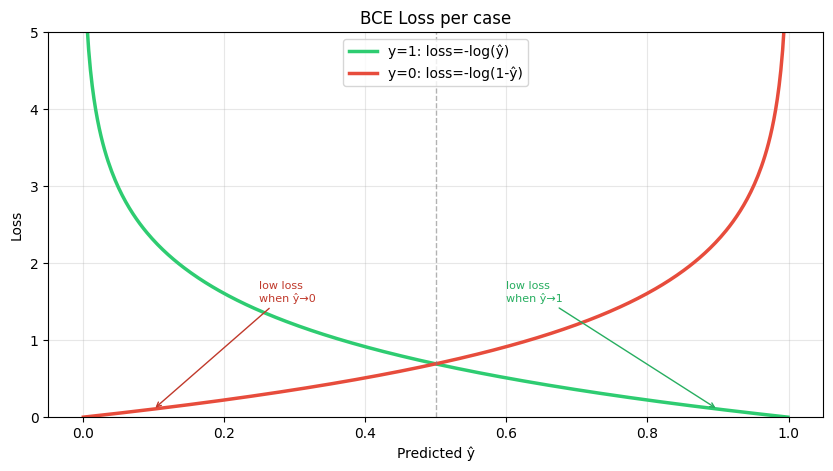

In [50]:
fig, ax1 = plt.subplots(1,1, figsize=(10, 5))
yh = np.linspace(0.001, 0.999, 400)
ax1.plot(yh, -np.log(yh),   color='#2ecc71', lw=2.5, label='y=1: loss=-log(ŷ)')
ax1.plot(yh, -np.log(1-yh), color='#e74c3c', lw=2.5, label='y=0: loss=-log(1-ŷ)')
ax1.axvline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
ax1.set(ylim=(0,5), xlabel='Predicted ŷ', ylabel='Loss', title='BCE Loss per case')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax1.annotate('low loss\nwhen ŷ→1', xy=(0.9,0.1), xytext=(0.6,1.5),
             arrowprops=dict(arrowstyle='->', color='#27ae60'), fontsize=8, color='#27ae60')
ax1.annotate('low loss\nwhen ŷ→0', xy=(0.1,0.1), xytext=(0.25,1.5),
             arrowprops=dict(arrowstyle='->', color='#c0392b'), fontsize=8, color='#c0392b')


Table representation

In [52]:
yh = np.array([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99])
df = pd.DataFrame({
    'ŷ (predicted prob)':     yh,
    'log(ŷ)':                 np.log(yh),          # used when y=1
    'log(1-ŷ)':               np.log(1 - yh),      # used when y=0
    'BCE loss if y=1':        -np.log(yh),          # = -log(ŷ)
    'BCE loss if y=0':        -np.log(1 - yh),      # = -log(1-ŷ)
}).round(4)
df

,ŷ (predicted prob),log(ŷ),log(1-ŷ),BCE loss if y=1,BCE loss if y=0
0,0.01,-4.6052,-0.0101,4.6052,0.0101
1,0.05,-2.9957,-0.0513,2.9957,0.0513
2,0.10,-2.3026,-0.1054,2.3026,0.1054
3,0.20,-1.6094,-0.2231,1.6094,0.2231
4,0.30,-1.2040,-0.3567,1.2040,0.3567
5,0.50,-0.6931,-0.6931,0.6931,0.6931
6,0.70,-0.3567,-1.2040,0.3567,1.2040
7,0.80,-0.2231,-1.6094,0.2231,1.6094
8,0.90,-0.1054,-2.3026,0.1054,2.3026
9,0.95,-0.0513,-2.9957,0.0513,2.9957
